# YOLOv11 Training on SKU-110k Dataset

This notebook trains a YOLOv11 model on the densely packed [SKU-110k dataset](https://docs.ultralytics.com/datasets/detect/sku-110k/) using [Ultralytics](https://docs.ultralytics.com/).

### Configuration:
* **Model:** YOLOv11s (Small)
* **Epochs:** 50
* **Image Size:** 1024x1024
* **Batch Size:** Auto (`batch=-1`)
* **Checkpointing:** Saves `best.pt` (for overfitting protection) and explicit checkpoints every 5 epochs.
* **Metrics:** AP@0.5, AP@0.75, AP@0.5-0.95, and AR@100 (via `pycocotools`).

### References:
* [Ultralytics Train Settings](https://docs.ultralytics.com/modes/train/#train-settings)
* [SKU-110k Dataset Docs](https://docs.ultralytics.com/datasets/detect/sku-110k/)

In [1]:
# @title 1. Environment Setup
# Install the ultralytics package
!pip install ultralytics

# Check GPU status
!nvidia-smi

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 29.4 MB/s eta 0:00:00
Wed Dec 24 22:44:35 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA L4                      Off |   00000000:00:03.0 Off |                    0 |
| N/A   42C    P8             12W /   72W |       0MiB /  23034MiB |      0%      Default |
|                                         |                    

In [2]:
# @title 2. Import and Initialize
import ultralytics
from ultralytics import YOLO
import torch

# Check Ultralytics version and GPU availability
print(f"Ultralytics version: {ultralytics.__version__}")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA Available: {torch.cuda.is_available()}")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics version: 8.3.241
PyTorch version: 2.9.0+cu126
CUDA Available: True


In [ ]:
# @title 3. Train YOLOv11
# We use 'yolo11s.pt' (Small)

# Load the model
model = YOLO('yolo11s.pt')

# Start Training
# Arguments:
# - data='SKU-110K.yaml': Auto-downloads dataset and configures paths
# - epochs=50
# - imgsz=1024
# - batch=-1: AutoBatch (optimizes batch size for your specific GPU memory)
# - save=True: Ensures 'best.pt' is saved (guards against overfitting by keeping the best performing epoch)
# - save_period=5: Saves a separate checkpoint file every 5 epochs

results = model.train(
    data='SKU-110K.yaml',
    epochs=50,
    imgsz=1024,
    batch=-1,
    project='sku110k_training',
    name='yolo11_sku_run',
    exist_ok=True,
    plots=True,
    save=True,
    save_period=5,
    patience=5
)

Ultralytics 8.3.241 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (NVIDIA L4, 22693MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=-1, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=SKU-110K.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=1024, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11s.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=yolo11_sku_run, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=5, perspective=0.0, plots=True, pose=12.0, pr

In [4]:
!zip -r /content/file.zip /content/sku110k_training/


  adding: content/sku110k_training/ (stored 0%)
  adding: content/sku110k_training/yolo11_sku_run/ (stored 0%)
  adding: content/sku110k_training/yolo11_sku_run/val_batch2_labels.jpg (deflated 5%)
  adding: content/sku110k_training/yolo11_sku_run/val_batch0_pred.jpg (deflated 2%)
  adding: content/sku110k_training/yolo11_sku_run/train_batch1.jpg (deflated 3%)
  adding: content/sku110k_training/yolo11_sku_run/results.png (deflated 8%)
  adding: content/sku110k_training/yolo11_sku_run/val_batch0_labels.jpg (deflated 2%)
  adding: content/sku110k_training/yolo11_sku_run/BoxF1_curve.png (deflated 16%)
  adding: content/sku110k_training/yolo11_sku_run/weights/ (stored 0%)
  adding: content/sku110k_training/yolo11_sku_run/weights/epoch5.pt (deflated 33%)
  adding: content/sku110k_training/yolo11_sku_run/weights/epoch35.pt (deflated 35%)
  adding: content/sku110k_training/yolo11_sku_run/weights/best.pt (deflated 8%)
  adding: content/sku110k_training/yolo11_sku_run/weights/epoch25.pt (deflate

In [ ]:
from google.colab import files
files.download("/content/file.zip")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### 4. Validation & Metrics
To see the **AR (Average Recall) of top 100**, we run validation with `save_json=True`.
This triggers the standard COCO evaluation protocol, which prints a detailed table including:
* `Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ]`
* `Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ]`
* `Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ]`
* `Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ]`

In [ ]:
# @title Run Full Validation

# Load the best model from the training run
best_model = YOLO('sku110k_training/yolo11_sku_run/weights/best.pt')

# Validate
# save_json=True is CRITICAL to get the AR@100 metric printed in the pycocotools table
metrics = best_model.val(data='SKU-110K.yaml', split='test', save_json=True)

# Print standard YOLO metrics (AP50, AP50-95)
print("\n--- Standard Ultralytics Metrics ---")
print(f"mAP@0.5: {metrics.box.map50:.4f}")
print(f"mAP@0.75: {metrics.box.map75:.4f}")
print(f"mAP@0.5-0.95: {metrics.box.map:.4f}")

Ultralytics 8.3.234 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
YOLO11s summary (fused): 100 layers, 9,413,187 parameters, 0 gradients, 21.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 95.5±27.6 MB/s, size: 1200.0 KB)
val: Scanning /content/datasets/SKU-110K/labels... 2935 images, 0 backgrounds, 1 corrupt: 100% ━━━━━━━━━━━━ 2936/2936 77.2it/s 38.0s
val: /content/datasets/SKU-110K/images/test_1029.jpg: corrupt JPEG restored and saved
val: /content/datasets/SKU-110K/images/test_1035.jpg: corrupt JPEG restored and saved
val: /content/datasets/SKU-110K/images/test_1059.jpg: corrupt JPEG restored and saved
val: /content/datasets/SKU-110K/images/test_1086.jpg: corrupt JPEG restored and saved
val: /content/datasets/SKU-110K/images/test_1090.jpg: corrupt JPEG restored and saved
val: /content/datasets/SKU-110K/images/test_1102.jpg: corrupt JPEG restored and saved
val: /content/datasets/SKU-110K/images/test_112.jpg: corrupt JPEG restored and saved
val: /content/da

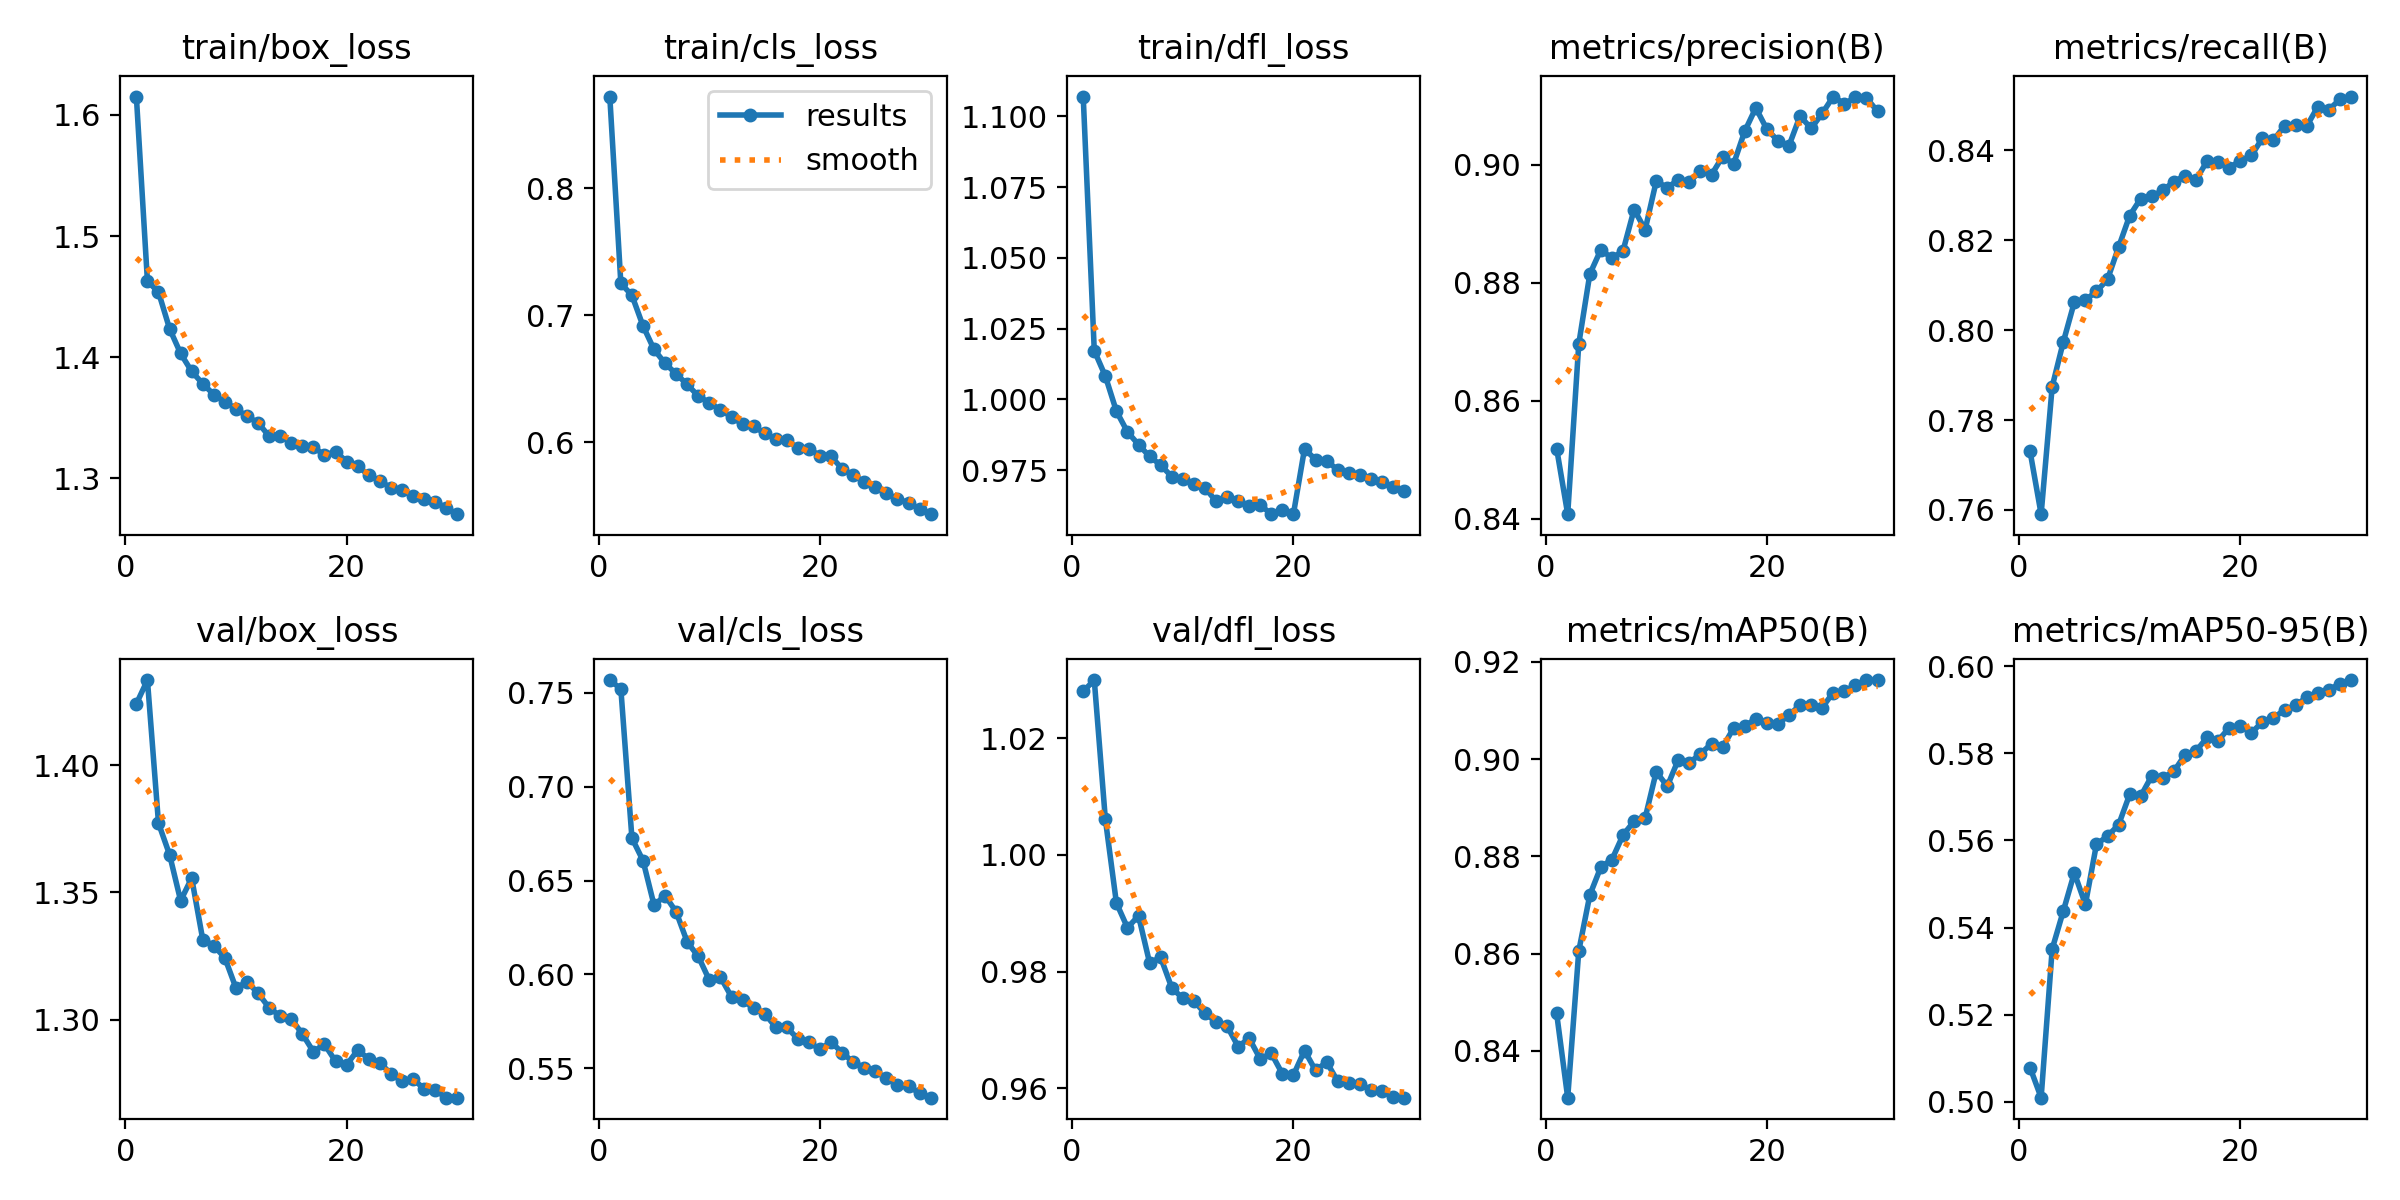

In [ ]:
# @title Display Training Graphs
from IPython.display import Image, display
import os

# Path to the results directory
results_dir = 'sku110k_training/yolo11_sku_run'

# Display results.png if it exists (Summary of losses and metrics)
results_img = os.path.join(results_dir, 'results.png')
if os.path.exists(results_img):
    display(Image(filename=results_img))
else:
    print("Results image not found.")